In [38]:
import pandas as pd
import numpy as np
#import data as csv
df = pd.read_csv(
    "fashion_trends_combined.csv"
)

print(df.describe(include='all'))

df["date"] = pd.to_datetime(
    df["date"]
)
df.category.value_counts(normalize=True)

              date   trend_name  google_score    category
count        12576        12576  12576.000000       12576
unique         262           48           NaN           9
top     2020-12-27  Romcom Core           NaN  Womenswear
freq            48          262           NaN        3144
mean           NaN          NaN     23.671040         NaN
std            NaN          NaN     25.464384         NaN
min            NaN          NaN      0.000000         NaN
25%            NaN          NaN      0.000000         NaN
50%            NaN          NaN     18.000000         NaN
75%            NaN          NaN     42.000000         NaN
max            NaN          NaN    100.000000         NaN


category
Womenswear             0.250000
Streetwear             0.166667
Accessories            0.145833
Footwear               0.125000
Denim                  0.083333
Sustainable Fashion    0.083333
Colour Trend           0.062500
Material Trend         0.062500
Unisex                 0.020833
Name: proportion, dtype: float64

In [39]:
#Feature Engineering 
#sort data
df = df.sort_values(
    ["trend_name", "date"])

#date features
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["quarter"] = df["date"].dt.quarter

#lag features 
for lag in [1,2,3]:

    df[f"lag_{lag}"] = (
        df.groupby("trend_name")
        ["google_score"]
        .shift(lag)
    )

#log growth rate 
df["growth_rate"] = (
    np.log1p(df["google_score"])
    - np.log1p(df["lag_1"])
)

#3 month rolling avg
df["rolling_3m"] = (
    df.groupby("trend_name")
      ["google_score"]
      .transform(
          lambda x:
          x.rolling(3).mean()
      )
)
#6 month rolling avg
df["rolling_6m"] = (
    df.groupby("trend_name")
      ["google_score"]
      .transform(
          lambda x:
          x.rolling(6).mean()
      )
)

#volatility
df["volatility_3m"] = (
    df.groupby("trend_name")
      ["google_score"]
      .transform(
          lambda x:
          x.rolling(3).std()
      )
)
#acceleration
df["previous_growth"] = (
    df.groupby("trend_name")
      ["growth_rate"]
      .shift(1)
)

df["acceleration"] = (
    df["growth_rate"]
    - df["previous_growth"]
)

In [40]:
#creating a prediction target 
#future score
df["future_score"] = (
    df.groupby("trend_name")
      ["google_score"]
      .shift(-3)
)
#future growth
df["future_log_growth"] = (
    np.log1p(df["future_score"])
    - np.log1p(df["google_score"])
)
#top 25% 
threshold = df["future_log_growth"].quantile(0.75)
#This defines "emerging trends" as the top quartile of future growth.
df["trend_status"] = (
    df["future_log_growth"] > threshold
).astype(int)

print(df.describe(include='all'))


                       date          trend_name  google_score    category  \
count                 12576               12576  12576.000000       12576   
unique                  NaN                  48           NaN           9   
top                     NaN  Adidas Samba Style           NaN  Womenswear   
freq                    NaN                 262           NaN        3144   
mean    2023-06-28 12:00:00                 NaN     23.671040         NaN   
min     2020-12-27 00:00:00                 NaN      0.000000         NaN   
25%     2022-03-27 00:00:00                 NaN      0.000000         NaN   
50%     2023-06-28 12:00:00                 NaN     18.000000         NaN   
75%     2024-09-29 00:00:00                 NaN     42.000000         NaN   
max     2025-12-28 00:00:00                 NaN    100.000000         NaN   
std                     NaN                 NaN     25.464384         NaN   

                year         month       quarter         lag_1         lag_

In [41]:
#create columns to drop NaNs
model_cols = [
    "lag_1",
    "lag_2",
    "lag_3",
    "rolling_3m",
    "rolling_6m",
    "volatility_3m",
    "acceleration",
    "trend_status"
]
#df with NaNs
print(df.shape)
#dropping nans and printing df_clean
df_clean = df.dropna(subset=model_cols)
print(df_clean.shape)
#checking percentage change between old and new df
rows_kept = len(df_clean) / len(df) * 100
print(f"{rows_kept:.1f}% of rows retained")

#drop missing valaues on specified columns 
df_model = df.dropna(subset=model_cols)
print(df_model.shape)
print(df_model.columns.tolist())


(12576, 19)
(12336, 19)
98.1% of rows retained
(12336, 19)
['date', 'trend_name', 'google_score', 'category', 'year', 'month', 'quarter', 'lag_1', 'lag_2', 'lag_3', 'growth_rate', 'rolling_3m', 'rolling_6m', 'volatility_3m', 'previous_growth', 'acceleration', 'future_score', 'future_log_growth', 'trend_status']


In [42]:
#define target (y) and features (x)
y = df_model["trend_status"]

features = [
    "lag_1",
    "lag_2",
    "lag_3",
    "growth_rate",
    "rolling_3m",
    "rolling_6m",
    "volatility_3m",
    "acceleration",
    "month",
    "quarter"
]

X = df_model[features]

#turn category into dummy features for modelling
X = pd.get_dummies(
    df_model[
        features + ["category"]
    ],
    drop_first=True
)

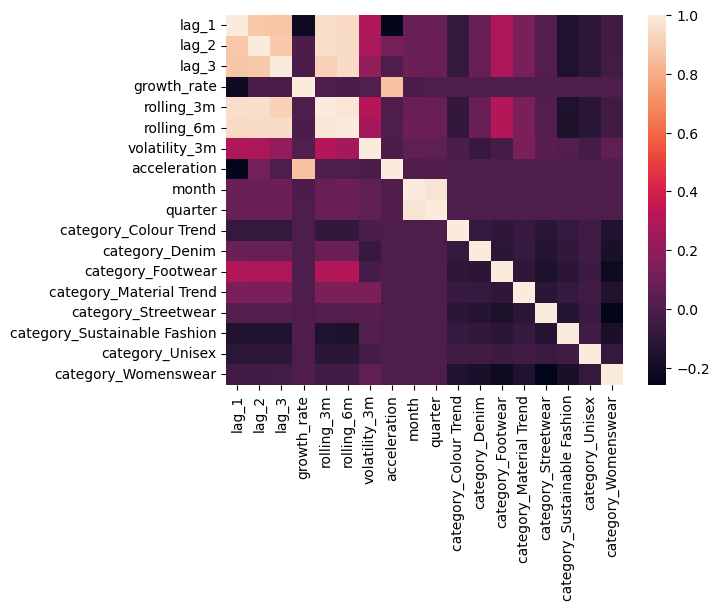

In [43]:
#Train test split 
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
import matplotlib.pyplot as plt
import seaborn as sns
#heatmap of X features
sns.heatmap(X.corr())
plt.show()
plt.close()

In [44]:
#Baseline Model LR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
#crate model lr
lr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression())
])
#train the model
lr_model.fit(X_train, y_train)

#make predictions
y_pred = lr_model.predict(X_test)
y_prob = lr_model.predict_proba(X_test)[:,1]


Accuracy: 0.7467585089141004
Precision: 0.4485981308411215
Recall: 0.0781758957654723
F1: 0.13314840499306518
ROC AUC: 0.6977619479319298
Confusion Matrix: [[1795   59]
 [ 566   48]]
            predicted no  predicted yes
actual no           1795             59
actual yes           566             48


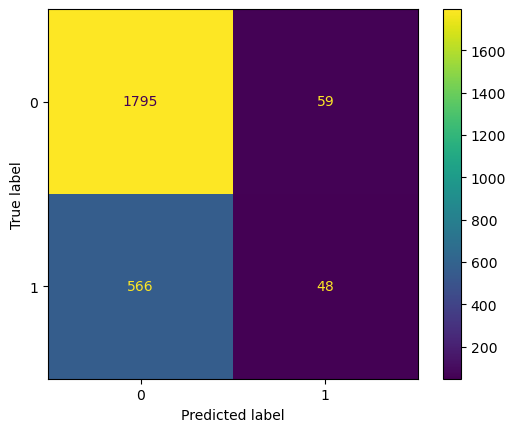

In [45]:
#Evaluation Metrics 
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve)

from sklearn.metrics import ConfusionMatrixDisplay

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print('Confusion Matrix:', confusion_matrix(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

test_conf_matrix = pd.DataFrame(
    confusion_matrix(y_test, y_pred), 
    index=['actual no', 'actual yes'], 
    columns=['predicted no', 'predicted yes'])
print(test_conf_matrix)


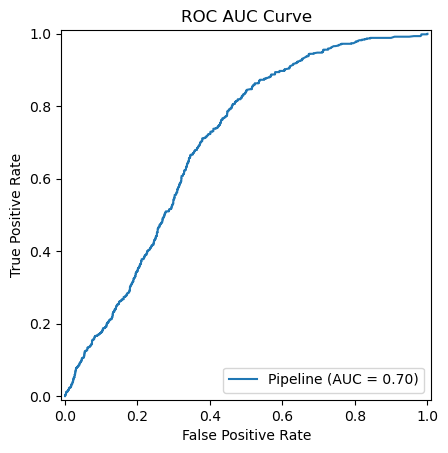

In [51]:
from sklearn.metrics import RocCurveDisplay
#Plot the ROC AUC Curve
# This automatically calculates probabilities and adds the AUC score to the legend
rcd = RocCurveDisplay.from_estimator(lr_model, X_test, y_test)

# 4. Customize and display the plot using matplotlib
plt.title("ROC AUC Curve")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()


Accuracy: 0.7921393841166937
ROC AUC: 0.813104160737063
Confusion Matrix: [[1710  144]
 [ 369  245]]
            predicted no  predicted yes
actual no           1710            144
actual yes           369            245


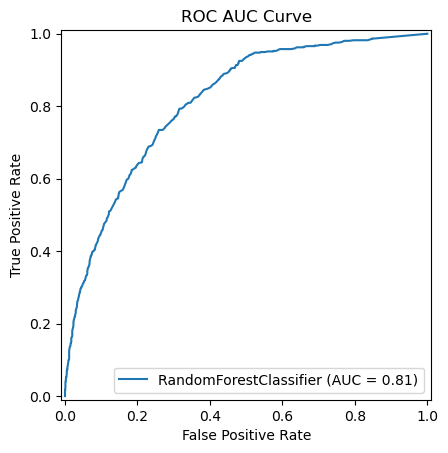

In [61]:
#Random forest 
from sklearn.ensemble import RandomForestClassifier
#instantiate model
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)
#training
rf.fit(X_train, y_train)
#predictions 
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("ROC AUC:", roc_auc_score(y_test, rf_prob))
print('Confusion Matrix:', confusion_matrix(y_test, rf_pred))
#matrix as a DF 
test_conf_matrix_rf = pd.DataFrame(
    confusion_matrix(y_test, rf_pred), 
    index=['actual no', 'actual yes'], 
    columns=['predicted no', 'predicted yes'])
print(test_conf_matrix_rf)

#Plot the ROC AUC Curve
# This automatically calculates probabilities and adds the AUC score to the legend
rcd2 = RocCurveDisplay.from_estimator(rf, X_test, y_test)

# 4. Customize and display the plot using matplotlib
plt.title("ROC AUC Curve")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

         Feature  Importance
5     rolling_6m    0.137841
3    growth_rate    0.120039
4     rolling_3m    0.118130
7   acceleration    0.101392
6  volatility_3m    0.099176
2          lag_3    0.098776
1          lag_2    0.082878
0          lag_1    0.081701
8          month    0.067442
9        quarter    0.025009


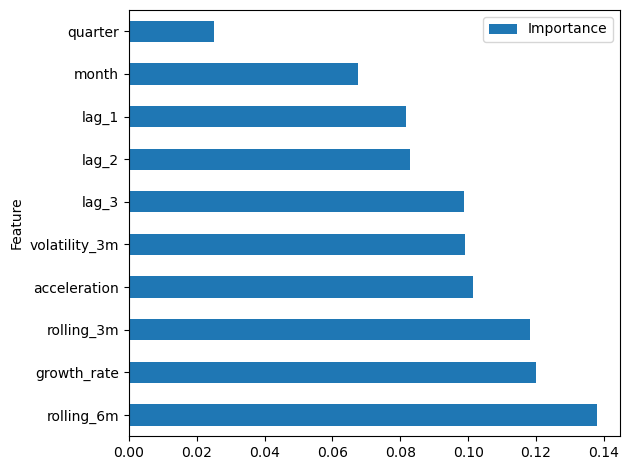

In [59]:
#Feature Importance
importance = pd.DataFrame({
    "Feature": X.columns, 
    "Importance": rf.feature_importances_})
importance = (importance.sort_values("Importance", ascending=False))
print(importance.head(10))

#plot importance
importance.head(10).plot(
    kind="barh",
    x="Feature",
    y="Importance"
)

plt.tight_layout()
plt.show()

#growth rate and the rolling six month search average were the strongest 
#predictors of trend emergence 


In [60]:
#Cross Validation
#estimate how well your model will perform on 
#unseen data than a single train/test split by training on 
#multiple splits of data 
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GroupKFold
scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="roc_auc"
)
print("Model Metrics for Standard Cross Validation:")
print("ROC AUC 5Fold:", scores)
print("Average ROC-AUC Performance:", scores.mean())
print("Standard Deviation:", scores.std())

      
#cross validation while keeping all the observations from trend_name together
#to ensure model has not already seen the trend in training as this can inflate performance
gkf = GroupKFold(n_splits=5)

scores = cross_val_score(
    rf,
    X,
    y,
    cv=gkf,
    groups=df_model["trend_name"],
    scoring="roc_auc"
)
print("Model Metrics for Group Cross Validation:")
print("ROC AUC GroupKFold:", scores)
print("Average ROC-AUC Performance:", scores.mean())
print("Standard Deviation:", scores.std())

#A 5-fold Group Cross-Validation strategy was employed using trend names 
#as grouping variables to prevent data leakage between 
#observations of the same trend. 

#The Random Forest model achieved a mean ROC-AUC of 0.78 (SD = 0.02), 
#indicating consistent predictive performance across unseen fashion trends.

#The Random Forest model with GroupKFold cross validation performed the best
#(ROC-AUC=0.78), compared to the Logistic regression model (ROC-AUC=:0.68) 

Model Metrics for Standard Cross Validation:
ROC AUC 5Fold: [0.70549239 0.74858645 0.75516857 0.86844865 0.75915278]
Average ROC-AUC Performance: 0.7673697683430029
Standard Deviation: 0.054064683770197824
Model Metrics for Group Cross Validation:
ROC AUC GroupKFold: [0.80888534 0.78221957 0.73667677 0.72611052 0.84346602]
Average ROC-AUC Performance: 0.7794716430692095
Standard Deviation: 0.043924498507324224
